# Лабораторная работа № 1
**Работа с изображениями: цветовые пространства, гистограммы, базовые фильтры (OpenCV)**

- **ФИО:** Алеуетдинов Алтынбек Габидинұлы
- **Группа:** SE-261
- **Дата:** 05.09.2026
- **Дисциплина:** Computer Vision (ANL7306)

Photo loaded successfully
Shape of image: (427, 640, 3)
Data type: uint8
Channel count: 3


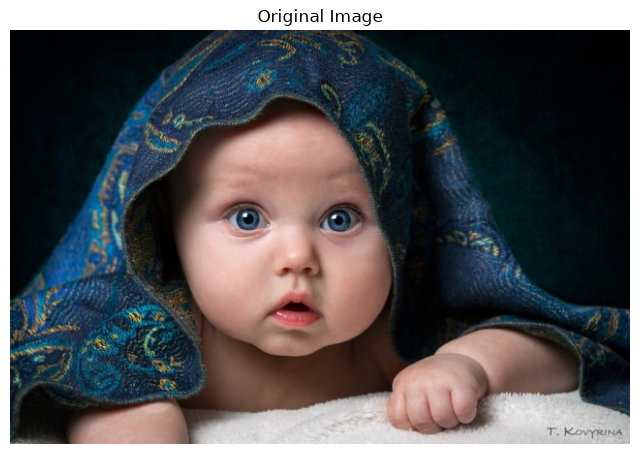

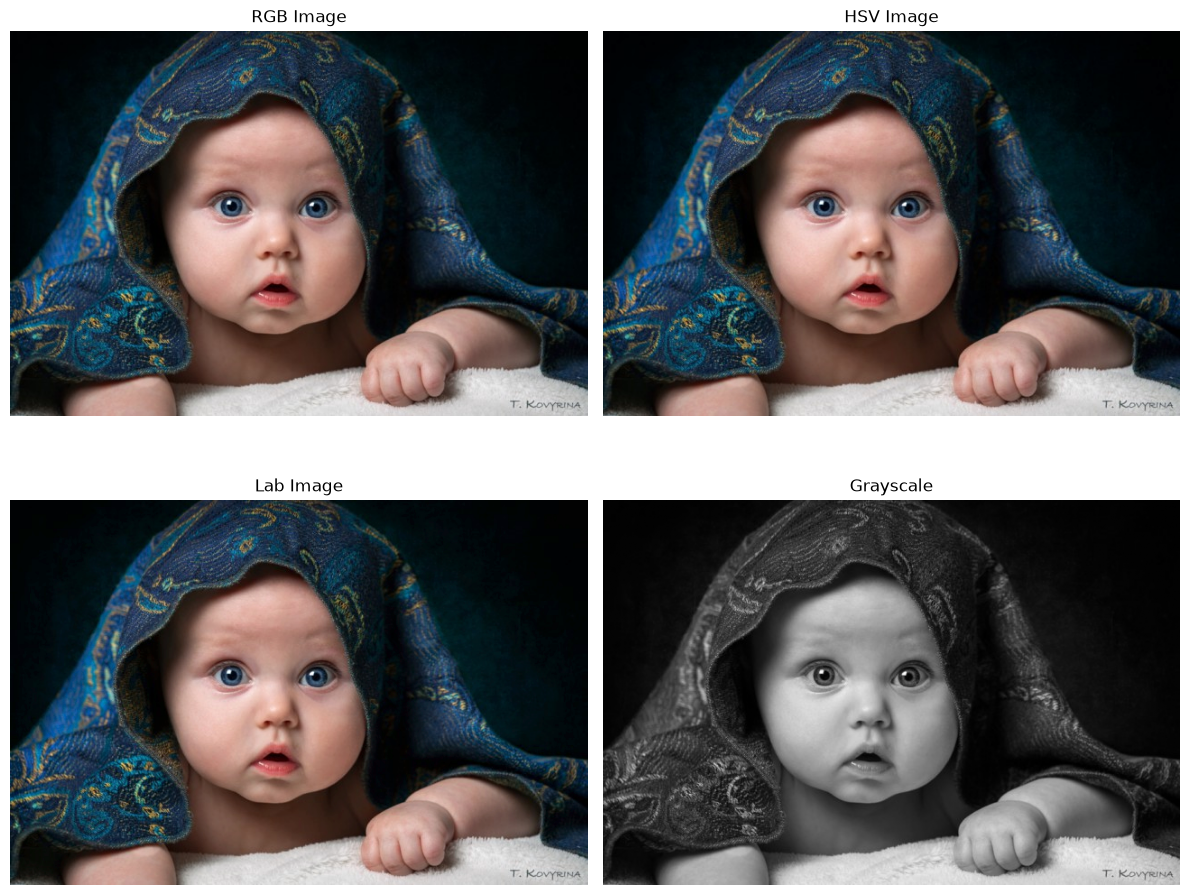

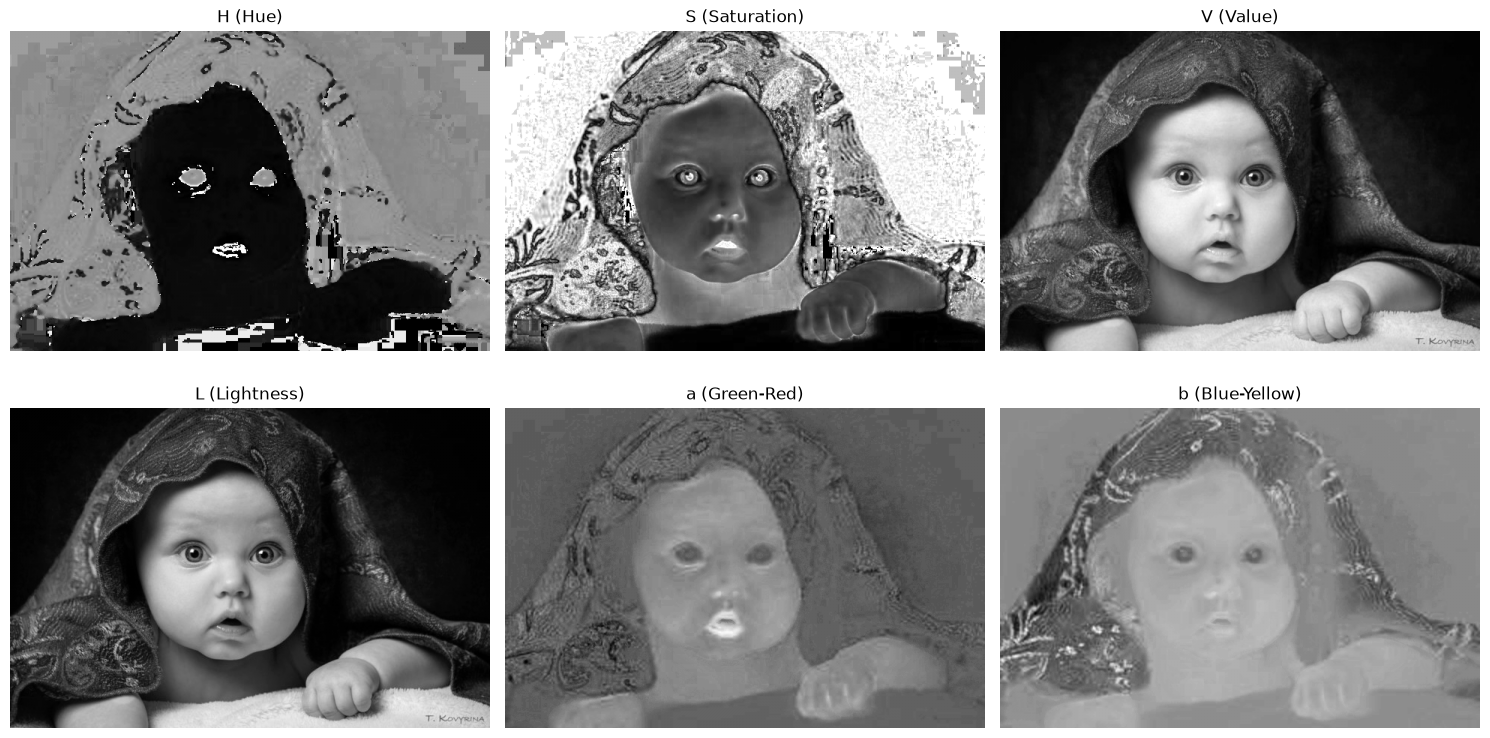

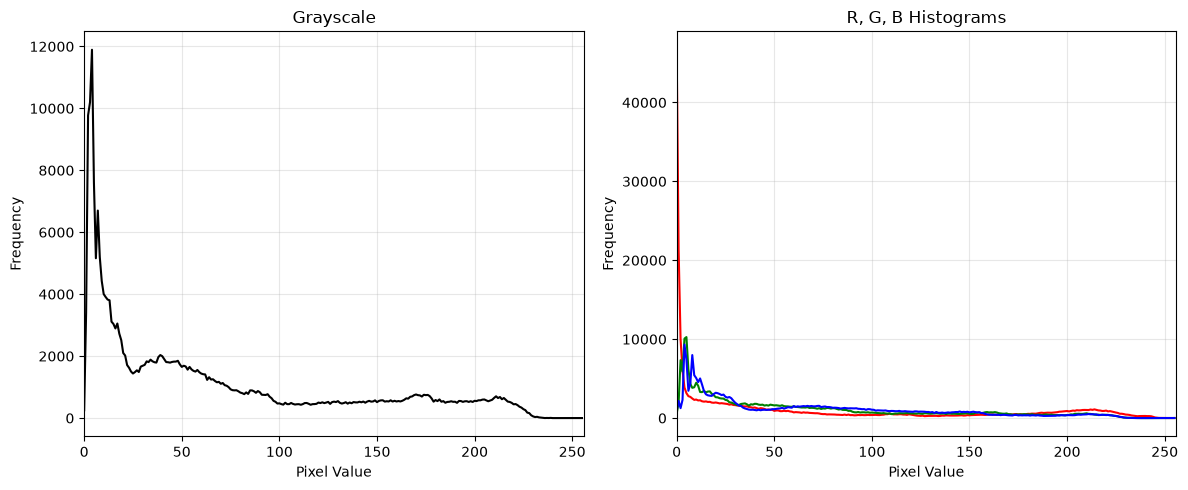

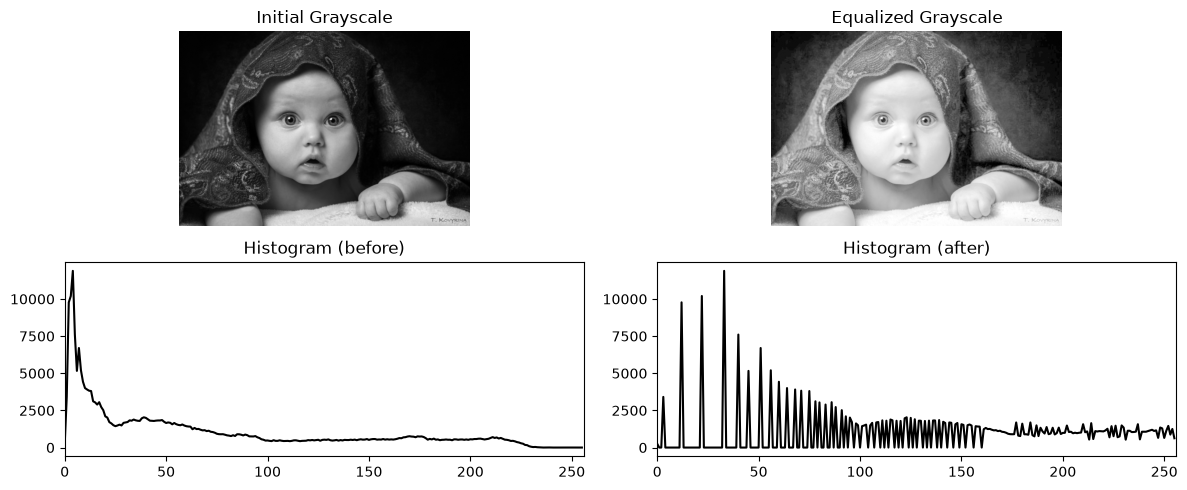

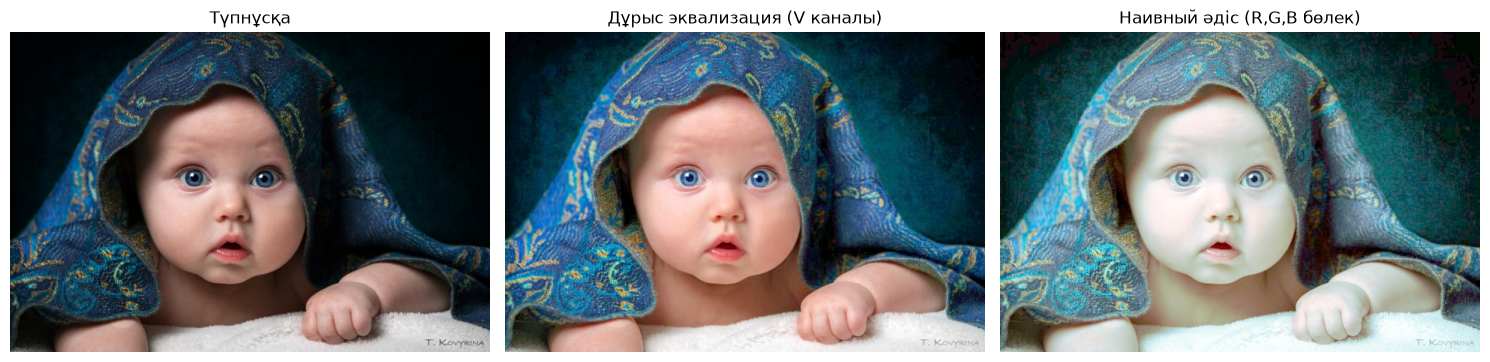

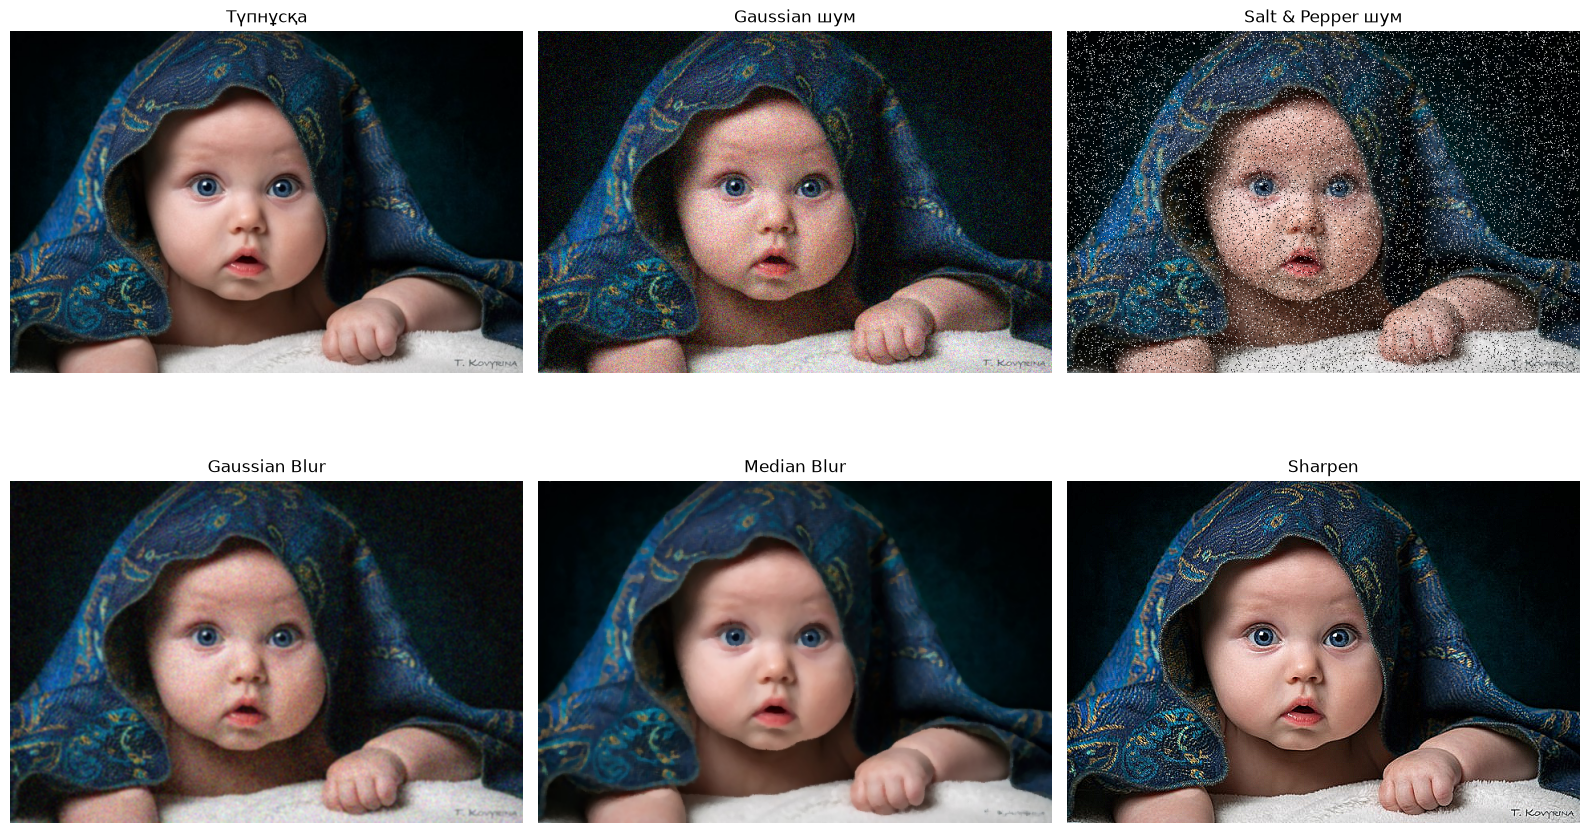

=== PSNR нәтижелері ===
Gaussian шум → Gaussian Blur: 28.83 dB
Salt&Pepper → Median Blur:    30.79 dB
Түпнұсқа → Sharpen:           23.63 dB


In [8]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL.ImageOps import equalize

def add_gaussian_noise(image, mean=0, sigma=25):
    noise = np.random.normal(mean, sigma, image.shape).astype(np.float32)
    noisy = image.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

def add_salt_pepper_noise(image, amount=0.05):
    noisy = image.copy()

    num_salt = np.ceil(amount * image.size * 0.5).astype(int)
    coords = [np.random.randint(0, i - 1, num_salt) for i in image.shape]
    noisy[coords[0], coords[1], :] = 255

    num_pepper = np.ceil(amount * image.size * 0.5).astype(int)
    coords = [np.random.randint(0, i - 1, num_pepper) for i in image.shape]
    noisy[coords[0], coords[1], :] = 0
    return noisy

def calculate_psnr(original, processed):
    mse = np.mean((original.astype(np.float32) - processed.astype(np.float32)) ** 2)
    if mse == 0:
        return 100
    return 20 * np.log10(255.0 / np.sqrt(mse))

#Start Task 1
img = cv2.imread('photo3.jpg')

if img is None:
    print("Photo is None")
else:
    print("Photo loaded successfully")
    print("Shape of image:", img.shape )
    print("Data type:", img.dtype )
    print("Channel count:", img.shape[2] if len(img.shape) == 3 else 1 )

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.title('Original Image')
    plt.axis('off')
    plt.show()

#Task 2

    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2Lab)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    plt.figure(figsize=(12, 10))

    plt.subplot(2, 2, 1)
    plt.imshow(img_rgb)
    plt.title('RGB Image')
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB))
    plt.title('HSV Image')
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.imshow(cv2.cvtColor(img_lab, cv2.COLOR_LAB2RGB))
    plt.title('Lab Image')
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.imshow(img_gray, cmap='gray')
    plt.title('Grayscale')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Task 2.2

    h, s, v = cv2.split(img_hsv)
    l, a, b = cv2.split(img_lab)

    plt.figure(figsize=(15, 8))

    # Channels HSV

    plt.subplot(2, 3, 1)
    plt.imshow(h, cmap='gray')
    plt.title('H (Hue)')
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(s, cmap='gray')
    plt.title('S (Saturation)')
    plt.axis('off')

    plt.subplot(2, 3, 3)
    plt.imshow(v, cmap='gray')
    plt.title('V (Value)')
    plt.axis('off')

    #Channels Lab
    plt.subplot(2, 3, 4)
    plt.imshow(l, cmap='gray')
    plt.title('L (Lightness)')
    plt.axis('off')

    plt.subplot(2, 3, 5)
    plt.imshow(a, cmap='gray')
    plt.title('a (Green-Red)')
    plt.axis('off')

    plt.subplot(2, 3, 6)
    plt.imshow(b, cmap='gray')
    plt.title('b (Blue-Yellow)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Task 3: Histograms

    plt.figure(figsize=(12, 5))

    #1. Luminance histogram of a grayscale image
    plt.subplot(1, 2, 1)
    hist_gray = cv2.calcHist([img_gray], [0], None, [256], [0, 256])
    plt.plot(hist_gray, color='black')
    plt.title("Grayscale")
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    plt.xlim([0, 256])
    plt.grid(True, alpha=0.3)

    #2.Histograms of the R, G, and B channels
    plt.subplot(1, 2, 2)
    colors = ('r', 'g', 'b')
    channels = cv2.split(img_rgb)

    for i, color in enumerate(colors):
        hist = cv2.calcHist([channels[i]], [0], None, [256], [0, 256])
        plt.plot(hist, color=color, label=color.upper())

    plt.title('R, G, B Histograms')
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    plt.xlim([0, 256])
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

#   Суреттің гистограммасы ортаңғы және жоғары жарықтық мәндеріне қарай ығысқан
#   (шамамен 100–220 аралығында пиктер бар). Бұл суреттің жақсы жарықталғанын
#   (нормальді экспозиция) көрсетеді. Контраст орташа деңгейде — пикселдердің мәндері
#   кең диапазонға таралған, бірақ өте қараңғы (0-ға жақын) және өте ашық (255-ке
#   жақын) аймақтар аз.

    # Task 4. Histogram equalization

    # 1. Applying equalizeHist to a grayscale image
    img_eq = cv2.equalizeHist(img_gray)

    # 2. Comparing the result
    plt.figure(figsize=(12, 5))

    plt.subplot(2, 2, 1)
    plt.imshow(img_gray, cmap='gray')
    plt.title('Initial Grayscale')
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(img_eq, cmap='gray')
    plt.title('Equalized Grayscale')
    plt.axis('off')

    # Histograms
    plt.subplot(2, 2, 3)
    hist_before = cv2.calcHist([img_gray], [0], None, [256], [0, 256])
    plt.plot(hist_before, color='black')
    plt.title('Histogram (before)')
    plt.xlim([0, 256])

    plt.subplot(2, 2, 4)
    hist_after = cv2.calcHist([img_eq], [0], None, [256], [0, 256])
    plt.plot(hist_after, color='black')
    plt.title('Histogram (after)')
    plt.xlim([0, 256])

    plt.tight_layout()
    plt.show()

    #Task 4.2
    # Түсті суретке эквализация (тек Value каналы бойынша)

    # 1. HSV-ге өту
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)

    # 2. Тек V каналын теңестіру
    v_eq = cv2.equalizeHist(v)

    # 3. Қайта біріктіру
    hsv_eq = cv2.merge([h, s, v_eq])
    img_eq_color = cv2.cvtColor(hsv_eq, cv2.COLOR_HSV2BGR)
    img_eq_color_rgb = cv2.cvtColor(img_eq_color, cv2.COLOR_BGR2RGB)

    # 4. Наивный әдіс (әр R,G,B-ға бөлек equalizeHist)
    r, g, b = cv2.split(img_rgb)
    r_eq = cv2.equalizeHist(r)
    g_eq = cv2.equalizeHist(g)
    b_eq = cv2.equalizeHist(b)
    img_naive = cv2.merge([r_eq, g_eq, b_eq])

    # Нәтижені көрсету
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img_rgb)
    plt.title('Түпнұсқа')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(img_eq_color_rgb)
    plt.title('Дұрыс эквализация (V каналы)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(img_naive)
    plt.title('Наивный әдіс (R,G,B бөлек)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


    # Task 5. Шум қосу және фильтрлеу
    # Шум қосу

    img_gauss = add_gaussian_noise(img)
    img_sp = add_salt_pepper_noise(img)

    # Фильтрлер
    gauss_blur = cv2.GaussianBlur(img_gauss, (5, 5), 0)
    median_blur = cv2.medianBlur(img_sp, 5)

    # Резкость фильтрі
    kernel_sharpen = np.array([[0, -1, 0],
                               [-1, 5, -1],
                               [0, -1, 0]])
    sharpened = cv2.filter2D(img, -1, kernel_sharpen)



    # Нәтижелерді көрсету
    plt.figure(figsize=(16, 10))

    images = [
        (img_rgb, "Түпнұсқа"),
        (cv2.cvtColor(img_gauss, cv2.COLOR_BGR2RGB), "Gaussian шум"),
        (cv2.cvtColor(img_sp, cv2.COLOR_BGR2RGB), "Salt & Pepper шум"),
        (cv2.cvtColor(gauss_blur, cv2.COLOR_BGR2RGB), "Gaussian Blur"),
        (cv2.cvtColor(median_blur, cv2.COLOR_BGR2RGB), "Median Blur"),
        (cv2.cvtColor(sharpened, cv2.COLOR_BGR2RGB), "Sharpen")
    ]

    for i, (im, title) in enumerate(images):
        plt.subplot(2, 3, i+1)
        plt.imshow(im)
        plt.title(title)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    # PSNR мәндерін шығару
    print("=== PSNR нәтижелері ===")
    print(f"Gaussian шум → Gaussian Blur: {calculate_psnr(img, gauss_blur):.2f} dB")
    print(f"Salt&Pepper → Median Blur:    {calculate_psnr(img, median_blur):.2f} dB")
    print(f"Түпнұсқа → Sharpen:           {calculate_psnr(img, sharpened):.2f} dB")


# Gaussian шум үшін Gaussian Blur, ал Salt-and-Pepper шуы үшін Median Blur ең тиімді.
# Median фильтр импульстік шуды жақсы жояды, себебі ол орташа мәнді емес, медиананы
# алады. Резкость фильтрі детальдарды күшейтеді, бірақ PSNR төмендеуі мүмкін.

# Task 6

# Менің суретімде мысықтың жүні мен фонның түсін ажырату үшін HSV түстер кеңістігі ең
# қолайлы. Себебі Hue каналы түсті жарықтықтан бөлек сақтайды, сондықтан белгілі бір
# түс диапазонын оңай бөліп алуға болады.



## Выводы

В ходе лабораторной работы я освоил базовые операции работы с изображениями в OpenCV: загрузку, отображение, преобразование цветовых пространств (RGB, HSV, Lab, Grayscale), построение гистограмм и применение фильтров.

Наиболее интересным оказалось сравнение правильной эквализации гистограммы по каналу Value в HSV и наивного метода по каналам R, G, B — последний сильно искажает цвета.

Также стало понятно, что Median Blur лучше справляется с Salt-and-Pepper шумом, а Gaussian Blur — с гауссовым шумом. Метрика PSNR помогла количественно оценить качество фильтрации.

Для задачи выделения объектов по цвету на моём изображении лучше всего подходит пространство HSV, так как канал Hue позволяет отделять цвет от яркости.